In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pyDOE import lhs
import os
import shutil
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Material properties
E = 20.0       # Young's modulus
mu = 0.25      # Poisson's ratio
hole_r = 0.1   # Hole radius
PI = math.pi


Using: cpu


In [4]:
class SimpleNN(nn.Module):
    """Unified model for distance, part, and uv networks"""
    def __init__(self, n_input=2, n_output=5, n_hidden=20, n_layers=4):
        super().__init__()
        layers = [nn.Linear(n_input, n_hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.Tanh()]
        layers.append(nn.Linear(n_hidden, n_output))
        self.net = nn.Sequential(*layers)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    m.bias.data.zero_()
    
    def forward(self, x):
        return self.net(x)


In [5]:
def generate_domain_points(num=100, num_surf=40):
    """Generate points in domain [0,0.5]x[0,0.5] excluding hole"""
    x = np.linspace(0, 0.5, num)
    y = np.linspace(0, 0.5, num)
    x, y = np.meshgrid(x, y)
    
    # Remove points inside hole
    dist = np.sqrt(x**2 + y**2)
    x, y = x[dist >= hole_r], y[dist >= hole_r]
    
    # Add surface refinement points
    theta = np.linspace(0, PI/2, num_surf)
    x_surf = hole_r * np.cos(theta)
    y_surf = hole_r * np.sin(theta)
    
    x = np.concatenate([x.flatten(), x_surf])[:, None]
    y = np.concatenate([y.flatten(), y_surf])[:, None]
    return np.hstack([x, y])

def compute_distance_targets(xy):
    """Compute distance function targets for boundary conditions"""
    n = len(xy)
    dist_u = xy[:, 0:1]                    # distance to left (x=0)
    dist_v = xy[:, 1:2]                    # distance to bottom (y=0)
    dist_s11 = 0.5 - xy[:, 0:1]            # distance to right (x=0.5)
    dist_s22 = 0.5 - xy[:, 1:2]            # distance to top (y=0.5)
    dist_s12 = np.minimum.reduce([xy[:, 0:1], 0.5-xy[:, 0:1], 
                                   xy[:, 1:2], 0.5-xy[:, 1:2]])
    return np.hstack([dist_u, dist_v, dist_s11, dist_s22, dist_s12])

def generate_boundary_points():
    """Generate boundary condition points"""
    # Hole surface
    theta = np.linspace(0, PI/2, 1000)
    hole = np.column_stack([hole_r * np.cos(theta), hole_r * np.sin(theta)])
    
    # Edges (using Latin Hypercube Sampling)
    lw = np.array([0.1, 0]) + np.array([0.4, 0]) * lhs(2, 5000)  # Lower
    up = np.array([0, 0.5]) + np.array([0.5, 0]) * lhs(2, 5000)  # Upper
    lf = np.array([0, 0.1]) + np.array([0, 0.4]) * lhs(2, 5000)  # Left
    rt = np.array([0.5, 0]) + np.array([0, 0.5]) * lhs(2, 8000)  # Right
    
    # Applied stress on right edge
    s11_rt = np.ones((len(rt), 1))
    rt = np.hstack([rt, s11_rt])
    
    return hole, lw, up, lf, rt

def generate_collocation_points():
    """Generate collocation points for PDE residuals"""
    xy_c = np.array([0, 0]) + np.array([0.5, 0.5]) * lhs(2, 5000)
    xy_ref = np.array([0.2, 0.2]) * lhs(2, 2000)  # Refinement near hole
    xy_c = np.vstack([xy_c, xy_ref])
    
    # Remove points inside hole
    dist = np.sqrt(xy_c[:, 0]**2 + xy_c[:, 1]**2)
    return xy_c[dist > hole_r]


In [6]:
# Distance function training data
XY_dist = generate_domain_points(num=100, num_surf=40)
DIST = compute_distance_targets(XY_dist)

# Boundary points
HOLE, LW, UP, LF, RT = generate_boundary_points()

# Collocation points
XY_c = generate_collocation_points()

# Add boundary samples to collocation
XY_c = np.vstack([XY_c, HOLE, LF[::5], RT[::5, :2], UP[::5], LW[::5]])

# Regenerate hole points to match collocation size
theta = np.linspace(0, PI/2, len(XY_c))
HOLE = np.column_stack([hole_r * np.cos(theta), hole_r * np.sin(theta)])

# Convert to tensors
to_tensor = lambda x: torch.FloatTensor(x).requires_grad_(True).to(device)
XY_dist_t, DIST_t = to_tensor(XY_dist), to_tensor(DIST)
HOLE_t, LW_t, UP_t, LF_t, RT_t = [to_tensor(x) for x in [HOLE, LW, UP, LF, RT]]
XY_t = to_tensor(XY_c)

print(f"Collocation points: {len(XY_c)}, Boundary points: {len(HOLE)}")


Collocation points: 12057, Boundary points: 12057


In [7]:
torch.manual_seed(123)
model_dist = SimpleNN(n_hidden=20, n_layers=4).to(device)
optimizer_dist = torch.optim.Adam(model_dist.parameters(), lr=1e-3)

print("Training Distance Model...")
for epoch in range(1000):
    optimizer_dist.zero_grad()
    pred = model_dist(XY_dist_t)
    loss = 1000 * torch.mean((pred - DIST_t)**2)
    loss.backward()
    optimizer_dist.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

print(f"Final distance loss: {loss.item():.6f}")


Training Distance Model...
Epoch 0: Loss = 87.612671
Epoch 200: Loss = 0.717182
Epoch 400: Loss = 0.704323
Epoch 600: Loss = 0.689014
Epoch 800: Loss = 0.669881
Final distance loss: 0.641970


In [8]:
torch.manual_seed(123)
model_part = SimpleNN(n_hidden=20, n_layers=4).to(device)
optimizer_part = torch.optim.Adam(model_part.parameters(), lr=1e-3)

print("\nTraining Particular Solution Model...")
for epoch in range(500):
    optimizer_part.zero_grad()
    
    # Boundary condition losses
    loss = 0
    loss += torch.mean(model_part(LF_t)[:, [0, 4]]**2)      # Left: u=0, s12=0
    loss += torch.mean(model_part(UP_t)[:, [3, 4]]**2)      # Top: s22=0, s12=0
    loss += torch.mean(model_part(LW_t)[:, [1, 4]]**2)      # Bottom: v=0, s12=0
    pred_rt = model_part(RT_t[:, :2])
    loss += torch.mean(pred_rt[:, 4]**2)                     # Right: s12=0
    loss += torch.mean((pred_rt[:, 2] - RT_t[:, 2])**2)     # Right: s11=applied
    
    loss = 1000 * loss
    loss.backward()
    optimizer_part.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

print(f"Final particular loss: {loss.item():.6f}")



Training Particular Solution Model...
Epoch 0: Loss = 1623.139648
Epoch 100: Loss = 1.885008
Epoch 200: Loss = 0.310529
Epoch 300: Loss = 0.050756
Epoch 400: Loss = 0.020015
Final particular loss: 0.017540


In [9]:
torch.manual_seed(123)
model_uv = SimpleNN(n_hidden=70, n_layers=8).to(device)
optimizer_uv = torch.optim.Adam(model_uv.parameters(), lr=1e-4)

# Dataset
class PINNDataset(Dataset):
    def __init__(self, xy, hole):
        self.xy = xy
        self.hole = hole
    def __len__(self):
        return len(self.xy)
    def __getitem__(self, idx):
        return self.xy[idx], self.hole[idx]

loader = DataLoader(PINNDataset(XY_t, HOLE_t), batch_size=512, shuffle=True)

print("\nTraining Main PINN Model...")
n_epochs = 5  # Increase for better results

for epoch in range(n_epochs):
    epoch_loss = 0
    for xy, hole in loader:
        optimizer_uv.zero_grad()
        
        # Forward pass with distance weighting
        pred = model_uv(xy) * model_dist(xy) + model_part(xy)
        
        # Compute strains (gradients of displacement)
        e11 = torch.autograd.grad(pred[:, 0].sum(), xy, create_graph=True)[0][:, 0]
        e22 = torch.autograd.grad(pred[:, 1].sum(), xy, create_graph=True)[0][:, 1]
        e12_u = torch.autograd.grad(pred[:, 0].sum(), xy, create_graph=True)[0][:, 1]
        e12_v = torch.autograd.grad(pred[:, 1].sum(), xy, create_graph=True)[0][:, 0]
        e12 = e12_u + e12_v
        
        # Constitutive equations (plane stress)
        coef = E / (1 - mu**2)
        s11_pred = coef * (e11 + mu * e22)
        s22_pred = coef * (mu * e11 + e22)
        s12_pred = E * e12 / (2 * (1 + mu))
        
        # Constitutive residuals
        loss_const = (torch.mean((pred[:, 2] - s11_pred)**2) +
                      torch.mean((pred[:, 3] - s22_pred)**2) +
                      torch.mean((pred[:, 4] - s12_pred)**2))
        
        # Equilibrium equations
        ds11_dx = torch.autograd.grad(pred[:, 2].sum(), xy, create_graph=True)[0][:, 0]
        ds12_dy = torch.autograd.grad(pred[:, 4].sum(), xy, create_graph=True)[0][:, 1]
        ds22_dy = torch.autograd.grad(pred[:, 3].sum(), xy, create_graph=True)[0][:, 1]
        ds12_dx = torch.autograd.grad(pred[:, 4].sum(), xy, create_graph=True)[0][:, 0]
        
        loss_equil = torch.mean((ds11_dx + ds12_dy)**2) + torch.mean((ds22_dy + ds12_dx)**2)
        
        # Hole traction-free BC
        pred_hole = model_uv(hole) * model_dist(hole) + model_part(hole)
        nx, ny = -hole[:, 0] / hole_r, -hole[:, 1] / hole_r
        tx = pred_hole[:, 2] * nx + pred_hole[:, 4] * ny
        ty = pred_hole[:, 4] * nx + pred_hole[:, 3] * ny
        loss_hole = torch.mean(tx**2) + torch.mean(ty**2)
        
        # Total loss
        loss = 10 * (loss_const + loss_equil + loss_hole)
        loss.backward()
        optimizer_uv.step()
        epoch_loss += loss.item()
    
    print(f"Epoch {epoch}: Loss = {epoch_loss/len(loader):.6f}")



Training Main PINN Model...
Epoch 0: Loss = 398.101375
Epoch 1: Loss = 114.082296
Epoch 2: Loss = 74.738076
Epoch 3: Loss = 49.082874
Epoch 4: Loss = 30.646370


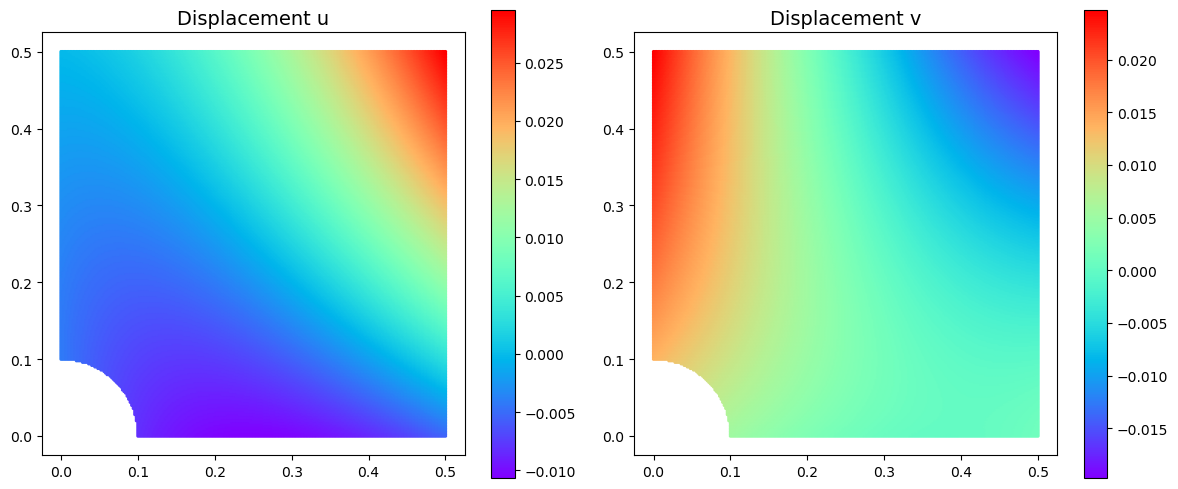

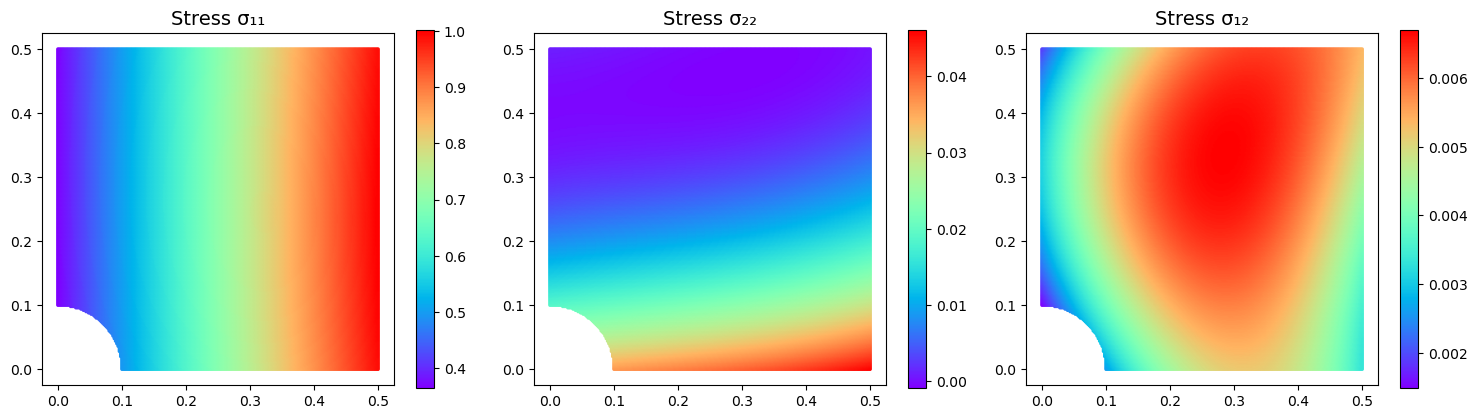

In [10]:
def plot_results(model_uv, model_dist, model_part):
    """Generate displacement and stress contour plots"""
    # Create evaluation grid
    x = np.linspace(0, 0.5, 251)
    y = np.linspace(0, 0.5, 251)
    X, Y = np.meshgrid(x, y)
    x_flat, y_flat = X.flatten()[:, None], Y.flatten()[:, None]
    
    # Remove points inside hole
    dist = np.sqrt(x_flat**2 + y_flat**2)
    mask = dist.flatten() >= hole_r
    x_plot, y_plot = x_flat[mask], y_flat[mask]
    
    # Predict
    xy = torch.FloatTensor(np.hstack([x_plot, y_plot])).to(device)
    with torch.no_grad():
        pred = model_uv(xy) * model_dist(xy) + model_part(xy)
    pred = pred.cpu().numpy()
    
    u, v = pred[:, 0], pred[:, 1]
    s11, s22, s12 = pred[:, 2], pred[:, 3], pred[:, 4]
    x_plot, y_plot = x_plot.flatten(), y_plot.flatten()
    
    # Plot displacements
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sc0 = axes[0].scatter(x_plot, y_plot, c=u, cmap='rainbow', s=2)
    axes[0].set_title('Displacement u', fontsize=14)
    axes[0].set_aspect('equal')
    plt.colorbar(sc0, ax=axes[0])
    
    sc1 = axes[1].scatter(x_plot, y_plot, c=v, cmap='rainbow', s=2)
    axes[1].set_title('Displacement v', fontsize=14)
    axes[1].set_aspect('equal')
    plt.colorbar(sc1, ax=axes[1])
    
    plt.tight_layout()
    plt.savefig('displacement.png', dpi=150)
    plt.show()
    
    # Plot stresses
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, data, title in zip(axes, [s11, s22, s12], 
                                ['σ₁₁', 'σ₂₂', 'σ₁₂']):
        sc = ax.scatter(x_plot, y_plot, c=data, cmap='rainbow', s=2)
        ax.set_title(f'Stress {title}', fontsize=14)
        ax.set_aspect('equal')
        plt.colorbar(sc, ax=ax)
    
    plt.tight_layout()
    plt.savefig('stress.png', dpi=150)
    plt.show()

# Generate plots
plot_results(model_uv, model_dist, model_part)
